# Model Creation

## Implement Model Using Sklearn

In [27]:
# Import all required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [28]:
# Read the dataframe using read_csv
df = pd.read_csv('../Salary_Data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [6]:
# Assign features and labels
X = df[['YearsExperience']] # features as a 2-D array
y = df['Salary']            # lables as a 1-D array

In [7]:
# Split the data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
# Train the model
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [9]:
print('Slope (m):', model.coef_)
print('Intercept (c):', model.intercept_)

Slope (m): [9423.81532303]
Intercept (c): 25321.583011776813


In [10]:
# Predict the output
model.predict([[12]])

array([138407.36688815])

In [11]:
# Find accuracy using score()
print(model.score(X_test,y_test))

0.9024461774180497


## Implement Model Using Gradient Descent

In [13]:
# Read the dataframe using read_csv
df = pd.read_csv('../Salary_Data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [29]:
# convert data columns to numpy arrays
X = df['YearsExperience'].values
y = df['Salary'].values

In [30]:
# Initialize Parameters
m, c = 0.0, 0.0
lr = 0.001
epochs = 2000
n = len(X)

In [31]:
# Gradient descent loop
loss_history = []
for i in range(epochs):
    Y_pred = m * X + c
    error = Y_pred - y

    loss = (1/n) * np.sum(error**2)
    loss_history.append(loss)

    dm = (2/n) * np.sum(error * X)
    dc = (2/n) * np.sum(error)

    m = m - (lr*dm)
    c = c - (lr*dc)

    if i % 500 == 0:
        print(f'epoch {i}: loss={loss:.2f} m={m:.3f} c={c:.3f}')
print('Final parameters -> m:', m, ' c:', c)

epoch 0: loss=6502955270.73 m=954.797 c=152.006
epoch 500: loss=111911174.00 m=12314.829 c=6486.626
epoch 1000: loss=84089419.34 m=11768.539 c=10167.929
epoch 1500: loss=65866472.94 m=11326.419 c=13147.259
Final parameters -> m: 10969.247352636694  c: 15554.141616378733


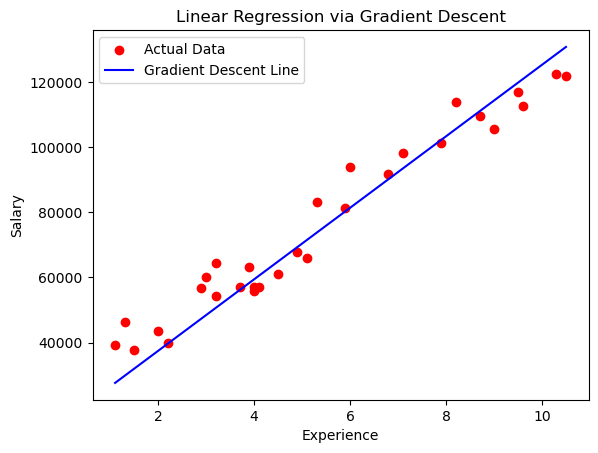

In [32]:
plt.scatter(X, y, color='red', label='Actual Data') 
plt.plot([min(X), max(X)], [min(m*X + c), max(m*X + c)], color='blue', label='Gradient Descent Line')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.title('Linear Regression via Gradient Descent')
plt.legend()
plt.show()

# Multiple Linear Regression

In [33]:
student_placement_data = pd.read_csv('../placement.csv')
student_placement_data

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [34]:
X = student_placement_data[['CGPA','IQ']]
y = student_placement_data['Placement_LPA']

KeyError: "None of [Index(['CGPA', 'IQ'], dtype='object')] are in the [columns]"

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [21]:
X_train

array([ 1.1,  2.2,  5.1,  2.9,  4.1,  4. ,  7.9,  1.3,  1.5,  9. ,  2. ,
        7.1,  9.5,  5.9, 10.5,  6.8,  3.2,  3.9,  4.5,  6. ,  3. ])

In [22]:
y_train

array([ 39343.,  39891.,  66029.,  56642.,  57081.,  55794., 101302.,
        46205.,  37731., 105582.,  43525.,  98273., 116969.,  81363.,
       121872.,  91738.,  54445.,  63218.,  61111.,  93940.,  60150.])

In [23]:
X_test

array([ 9.6,  4.9,  8.2,  5.3,  3.2,  3.7, 10.3,  8.7,  4. ])

In [24]:
y_test

array([112635.,  67938., 113812.,  83088.,  64445.,  57189., 122391.,
       109431.,  56957.])

In [25]:
model = LinearRegression()
model.fit(X_train,y_train)

ValueError: Expected 2D array, got 1D array instead:
array=[ 1.1  2.2  5.1  2.9  4.1  4.   7.9  1.3  1.5  9.   2.   7.1  9.5  5.9
 10.5  6.8  3.2  3.9  4.5  6.   3. ].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.

In [ ]:
print("Slope:",model.coef_)
print("Intercept:",model.intercept_)

In [26]:
y_pred = model.predict([[6.9,98]])
y_pred

NotFittedError: This LinearRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [3]:
print(model.score(X_test,y_test))

NameError: name 'model' is not defined